## Entrega Final

Licenciatura em Computação | UFPR Palotina

Aluna: Joyce Moura GRR 20231837


### Analisando o Dataset

O Dataset utilizado foi encontrado em dados abertos do governo brasileiro. É uma base de dados do Censo Escolar sobre microdados da educação básica do ano de 2023 (https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-escolar).

O Dataset vem compactado em um arquivo .zip, nesse arquivo contém além dos dados utilizados, vem um dicionário dos dados (explicando o nome das colunas e o significado das variavéis numéricas).




### Microdados Educação Básica

Esse Dataset contempla todos os estados e cidades do Brasil, no entanto, será feito uma filtragem para analisar apenas o Estado do Paraná.



### O problema a ser analisado

**A infraestrutura das escolas do Paraná impacta o número de matrículas?**

O Por que desse tema?

O Censo Escolar é a maior pesquisa estatística da educação básica brasileira, realizada anualmente pelo INEP. Reúne dados de todas as escolas do país — gratuita, oficial e confiável. O Paraná, com forte presença rural e urbana, é um bom recorte para investigar desigualdades educacionais.

Por que importa?

Entender essa relação pode ajudar gestores públicos a priorizar investimentos, contribuindo para reduzir a evasão escolar e melhorar a qualidade da educação no campo.

O que quero/queremos descobrir?

- Escolas rurais têm menos infraestrutura que escolas urbanas?
- Itens como internet, biblioteca e laboratório influenciam o número de alunos matriculados?
- É possível prever o número de matrículas com base na infraestrutura da escola?


In [1]:
#Importando o Pandas
import pandas as pd

#importando meu dataset - dados do governo brasileiro
df = "/content/microdados_ed_basica_2023.csv"

#adicionando o encoding e o separador de colunas
dados = pd.read_csv(df, encoding='latin1', sep=';')

#aqui pegamos as primeiras linhas do dataset
dados.head()

/tmp/ipykernel_65279/2677188371.py:8: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  dados = pd.read_csv(df, encoding='latin1', sep=';')


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,QT_TUR_BAS_D,QT_TUR_BAS_N,QT_TUR_BAS_EAD,QT_TUR_INF_INT,QT_TUR_INF_CRE_INT,QT_TUR_INF_PRE_INT,QT_TUR_FUND_INT,QT_TUR_FUND_AI_INT,QT_TUR_FUND_AF_INT,QT_TUR_MED_INT
0,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,14.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,38.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
#verificar os nomes das colunas
print(dados.columns.tolist())

['NU_ANO_CENSO', 'NO_REGIAO', 'CO_REGIAO', 'NO_UF', 'SG_UF', 'CO_UF', 'NO_MUNICIPIO', 'CO_MUNICIPIO', 'NO_REGIAO_GEOG_INTERM', 'CO_REGIAO_GEOG_INTERM', 'NO_REGIAO_GEOG_IMED', 'CO_REGIAO_GEOG_IMED', 'NO_MESORREGIAO', 'CO_MESORREGIAO', 'NO_MICRORREGIAO', 'CO_MICRORREGIAO', 'CO_DISTRITO', 'NO_ENTIDADE', 'CO_ENTIDADE', 'TP_DEPENDENCIA', 'TP_CATEGORIA_ESCOLA_PRIVADA', 'TP_LOCALIZACAO', 'TP_LOCALIZACAO_DIFERENCIADA', 'DS_ENDERECO', 'NU_ENDERECO', 'DS_COMPLEMENTO', 'NO_BAIRRO', 'CO_CEP', 'NU_DDD', 'NU_TELEFONE', 'TP_SITUACAO_FUNCIONAMENTO', 'CO_ORGAO_REGIONAL', 'DT_ANO_LETIVO_INICIO', 'DT_ANO_LETIVO_TERMINO', 'IN_VINCULO_SECRETARIA_EDUCACAO', 'IN_VINCULO_SEGURANCA_PUBLICA', 'IN_VINCULO_SECRETARIA_SAUDE', 'IN_VINCULO_OUTRO_ORGAO', 'IN_PODER_PUBLICO_PARCERIA', 'TP_PODER_PUBLICO_PARCERIA', 'IN_FORMA_CONT_TERMO_COLABORA', 'IN_FORMA_CONT_TERMO_FOMENTO', 'IN_FORMA_CONT_ACORDO_COOP', 'IN_FORMA_CONT_PRESTACAO_SERV', 'IN_FORMA_CONT_COOP_TEC_FIN', 'IN_FORMA_CONT_CONSORCIO_PUB', 'IN_FORMA_CONT_MU_TERMO_

In [3]:
# mostra quais valores existem na coluna
print(f"Total de linhas no dataset original: {len(dados)}")
print(dados['CO_UF'].unique())

Total de linhas no dataset original: 217625
[11 12 13 14 15 16 17 21 22 23 24 25 26 27 28 29 31 32 33 35 41 42 43 50
 51 52 53]


In [4]:
# Filtrando e salvando em um novo DataFrame chamado dados_pr
# aqui peguei a coluna do código da unidade da federação e caso ela for igual ao 41
# realizar uma filtragem para pegar o estado do paraná
dados_pr = dados[dados['CO_UF'] == 41]

# visualizando as primeiras linhas do novo dataset filtrado
dados_pr.head()

,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,QT_TUR_BAS_D,QT_TUR_BAS_N,QT_TUR_BAS_EAD,QT_TUR_INF_INT,QT_TUR_INF_CRE_INT,QT_TUR_INF_PRE_INT,QT_TUR_FUND_INT,QT_TUR_FUND_AI_INT,QT_TUR_FUND_AF_INT,QT_TUR_MED_INT
177504,2023,Sul,4,Paraná,PR,41,Alto Paraná,4100608,Maringá,4104,...,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177505,2023,Sul,4,Paraná,PR,41,Alto Paraná,4100608,Maringá,4104,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177506,2023,Sul,4,Paraná,PR,41,Alto Paraná,4100608,Maringá,4104,...,10.0,0.0,0.0,10.0,7.0,3.0,0.0,0.0,0.0,0.0
177507,2023,Sul,4,Paraná,PR,41,Alto Paraná,4100608,Maringá,4104,...,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177508,2023,Sul,4,Paraná,PR,41,Alto Paraná,4100608,Maringá,4104,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
#Renomeando o nome do dataset
dados_pr.to_csv('censo_parana_2023.csv')


In [6]:
#Visualizar o tamanho e as colunas disponíveis
print(f"Total de escolas no Paraná: {dados_pr.shape[0]}")
print(f"Total de colunas: {dados_pr.shape[1]}")

Total de escolas no Paraná: 9999
Total de colunas: 408


### Será que é preciso utilizar todas as colunas do dataset?

Ao analisar o dataset percebe-se que possui muitas colunas e para avaliar o  problema, talvez não seja preciso todas as colunas. Será avaliado os atributos para verificar a relação com o problema.

Nos slides disponibilizado pelo professor, diz que quanto mais colunas maior risco da maldição da dimensionalidade.

Quando for para a parte de treino e teste (Machine Learning) é bom analisar se realmente é necessário utilizar todas as colunas do dataset.


### Limpeza de Dados

Por que cada coluna foi escolhida?


Seleção de colunas importantes:
| Categoria | Variável | Descrição / Tipo de Dado |
| :--- | :--- | :--- |
| **1. Identificação** | `municipio` | Município onde a escola está localizada |
| | `dependencia` | Dependência administrativa (Federal, Estadual, Municipal ou Privada) |
| | `localizacao` | Zona de localização (Urbana ou Rural) |
| **2. Infraestrutura Básica** | `tem_agua_potavel` | Possui abastecimento de água potável (Sim/Não) |
| | `tem_energia` | Possui abastecimento de energia elétrica (Sim/Não) |
| | `tem_esgoto` | Possui esgotamento sanitário / saneamento básico (Sim/Não) |
| **3. Tecnologia** | `tem_internet` | Possui acesso à internet (Sim/Não) |
| | `tem_banda_larga` | Possui conexão de internet banda larga (Sim/Não) |
| | `tem_computador` | Possui computadores para uso (Sim/Não) |
| **4. Pedagogia** | `tem_biblioteca` | Possui biblioteca ou sala de leitura (Sim/Não) |
| | `tem_lab_informatica` | Possui laboratório de informática (Sim/Não) |
| | `tem_lab_ciencias` | Possui laboratório de ciências (Sim/Não) |
| **5. Estrutura Física** | `tem_quadra` | Possui quadra de esportes (Sim/Não) |
| | `tem_cozinha` | Possui cozinha (Sim/Não) |
| | `tem_refeitorio` | Possui refeitório (Sim/Não) |
| | `tem_banheiro_acessivel` | Possui banheiro adaptado para PCD (Sim/Não) |
| **6. Indicadores** | `qtd_salas` | Quantidade de salas de aula existentes |
| | `qtd_professores` | Quantidade total de professores |
| | `qtd_matriculas` | Quantidade total de alunos matriculados |


### Colunas descartadas

Algumas colunas possuiam muitos valores nulos e que não possuia muita relação com o problema. As colunas administrativas não dizem muito sobre infraestrutura (por exemplo: cnpj, telefone) e as colunas específicas não faz muito sentido no contexto (por exemplo: formas de contrato com o governo).


In [7]:
#Aqui foi selecionado as colunas que vai ajudar a responder o problema
colunas = [
    'NO_MUNICIPIO', 'TP_DEPENDENCIA', 'TP_LOCALIZACAO',
    'IN_AGUA_POTAVEL', 'IN_ENERGIA_REDE_PUBLICA', 'IN_ESGOTO_REDE_PUBLICA',
    'IN_INTERNET', 'IN_BANDA_LARGA', 'IN_COMPUTADOR',
    'IN_BIBLIOTECA', 'IN_LABORATORIO_INFORMATICA', 'IN_LABORATORIO_CIENCIAS',
    'IN_QUADRA_ESPORTES', 'IN_COZINHA', 'IN_REFEITORIO',
    'IN_BANHEIRO_PNE', 'QT_SALAS_UTILIZADAS',
    'QT_DOC_BAS', 'QT_MAT_BAS'
]

dados_pr = dados_pr[colunas].copy()
print(dados_pr.shape)

(9999, 19)


In [8]:
#Renomeando os nomes das colunas para um melhor entendimento
dados_pr = dados_pr.rename(columns={
    'NO_MUNICIPIO'              : 'municipio',
    'TP_DEPENDENCIA'            : 'dependencia',
    'TP_LOCALIZACAO'            : 'localizacao',
    'IN_AGUA_POTAVEL'           : 'tem_agua_potavel',
    'IN_ENERGIA_REDE_PUBLICA'   : 'tem_energia',
    'IN_ESGOTO_REDE_PUBLICA'    : 'tem_esgoto',
    'IN_INTERNET'               : 'tem_internet',
    'IN_BANDA_LARGA'            : 'tem_banda_larga',
    'IN_COMPUTADOR'             : 'tem_computador',
    'IN_BIBLIOTECA'             : 'tem_biblioteca',
    'IN_LABORATORIO_INFORMATICA': 'tem_lab_informatica',
    'IN_LABORATORIO_CIENCIAS'   : 'tem_lab_ciencias',
    'IN_QUADRA_ESPORTES'        : 'tem_quadra',
    'IN_COZINHA'                : 'tem_cozinha',
    'IN_REFEITORIO'             : 'tem_refeitorio',
    'IN_BANHEIRO_PNE'           : 'tem_banheiro_acessivel',
    'QT_SALAS_UTILIZADAS'       : 'qtd_salas',
    'QT_DOC_BAS'                : 'qtd_professores',
    'QT_MAT_BAS'                : 'qtd_matriculas'
})

dados_pr.head()

,municipio,dependencia,localizacao,tem_agua_potavel,tem_energia,tem_esgoto,tem_internet,tem_banda_larga,tem_computador,tem_biblioteca,tem_lab_informatica,tem_lab_ciencias,tem_quadra,tem_cozinha,tem_refeitorio,tem_banheiro_acessivel,qtd_salas,qtd_professores,qtd_matriculas
177504,Alto Paraná,2,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,12.0,30.0,468.0
177505,Alto Paraná,3,1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,6.0,10.0,207.0
177506,Alto Paraná,3,1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,11.0,10.0,150.0
177507,Alto Paraná,3,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,9.0,12.0,277.0
177508,Alto Paraná,3,1,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,4.0,3.0,26.0


In [9]:
#Visualizar as informações do dataset
dados_pr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 177504 to 187502
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   municipio               9999 non-null   object 
 1   dependencia             9999 non-null   int64  
 2   localizacao             9999 non-null   int64  
 3   tem_agua_potavel        9536 non-null   float64
 4   tem_energia             9536 non-null   float64
 5   tem_esgoto              9536 non-null   float64
 6   tem_internet            9536 non-null   float64
 7   tem_banda_larga         9464 non-null   float64
 8   tem_computador          9536 non-null   float64
 9   tem_biblioteca          9536 non-null   float64
 10  tem_lab_informatica     9536 non-null   float64
 11  tem_lab_ciencias        9536 non-null   float64
 12  tem_quadra              9536 non-null   float64
 13  tem_cozinha             9536 non-null   float64
 14  tem_refeitorio          9536 non-null 

### Tratamento de Valores Nulos



In [10]:
#Visualizar a quantidade de valores nulos
print(dados_pr.isnull().sum())

municipio                   0
dependencia                 0
localizacao                 0
tem_agua_potavel          463
tem_energia               463
tem_esgoto                463
tem_internet              463
tem_banda_larga           535
tem_computador            463
tem_biblioteca            463
tem_lab_informatica       463
tem_lab_ciencias          463
tem_quadra                463
tem_cozinha               463
tem_refeitorio            463
tem_banheiro_acessivel    463
qtd_salas                 463
qtd_professores           518
qtd_matriculas            514
dtype: int64


In [11]:
# Colunas binárias (sim/não)
# busca com todas as colunas que começam com o texto tem_
cols_binarias = [c for c in dados_pr.columns if c.startswith('tem_')]

#resposta em branco em relação ao tem_, o fillna(0) troca todos os vazios por zero.
dados_pr[cols_binarias] = dados_pr[cols_binarias].fillna(0).astype(int)

# Colunas numéricas
cols_numericas = ['qtd_salas', 'qtd_professores', 'qtd_matriculas']
dados_pr[cols_numericas] = dados_pr[cols_numericas].fillna(0).astype(int)

# Remove linhas essenciais nulas
# o subset indica que só vai deletar a linha caso faltar informações nas colunas escolhidas
dados_pr = dados_pr.dropna(subset=['municipio', 'localizacao', 'dependencia'])

print(f"Shape final: {dados_pr.shape}")

Shape final: (9999, 19)


In [12]:
#Tradução dos códigos uméricos
dados_pr['dependencia'] = dados_pr['dependencia'].map({
    1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'
})

dados_pr['localizacao'] = dados_pr['localizacao'].map({
    1: 'Urbana', 2: 'Rural'
})

print(dados_pr['dependencia'].value_counts())
print(dados_pr['localizacao'].value_counts())

dependencia
Municipal    5459
Privada      2370
Estadual     2140
Federal        30
Name: count, dtype: int64
localizacao
Urbana    8648
Rural     1351
Name: count, dtype: int64


### Análise Exploratória dos Dados



In [13]:
# Importandos as bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

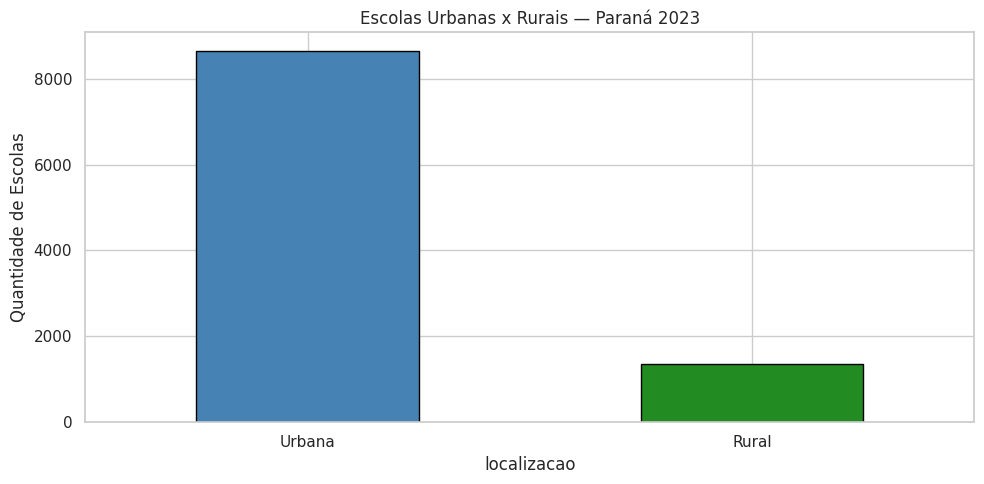

In [14]:
# Gráfico escolas urbanas X rurais
dados_pr['localizacao'].value_counts().plot(
    kind='bar', color=['steelblue', 'forestgreen'], edgecolor='black'
)
plt.title('Escolas Urbanas x Rurais — Paraná 2023')
plt.ylabel('Quantidade de Escolas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

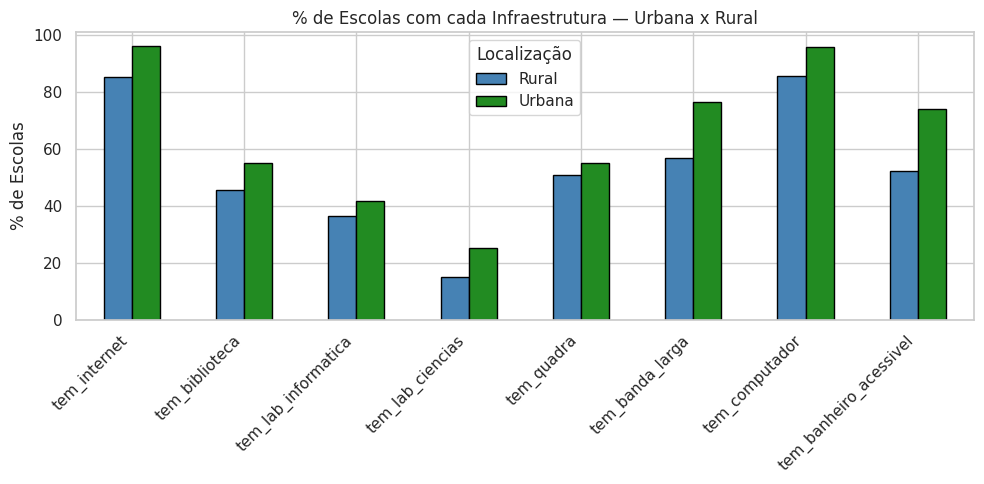

In [16]:
# Infraestrutura escolas urbanas X rurais
cols_infra = [
    'tem_internet', 'tem_biblioteca', 'tem_lab_informatica',
    'tem_lab_ciencias', 'tem_quadra', 'tem_banda_larga',
    'tem_computador', 'tem_banheiro_acessivel'
]

# o groupby separa o dataset em dois grupos (urbana x rural)
# mean * 100 calcular a porcentagem de cada grupo
infra_media = dados_pr.groupby('localizacao')[cols_infra].mean() * 100

infra_media.T.plot(kind='bar', color=['steelblue', 'forestgreen'], edgecolor='black')
plt.title('% de Escolas com cada Infraestrutura — Urbana x Rural')
plt.ylabel('% de Escolas')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Localização')
plt.tight_layout()
plt.show()

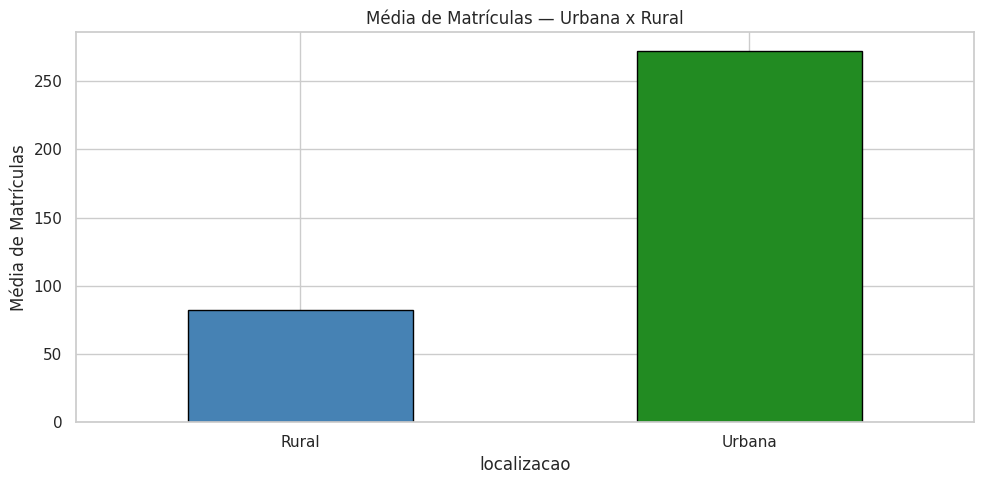

In [18]:
# Matrículas escolas urbana X rural

# Calculando a média da quantidade de matriculas por localização
dados_pr.groupby('localizacao')['qtd_matriculas'].mean().plot(
    kind='bar', color=['steelblue', 'forestgreen'], edgecolor='black'
)
plt.title('Média de Matrículas — Urbana x Rural')
plt.ylabel('Média de Matrículas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Correlação entre Infraestrura e N° de Matrículas

A Correlação de Pearson é uma medida estatística que avalia a força e a direção da relação linear entre duas variáveis quantitativas. Ela indica se duas variáveis crescem ou decrescem juntas em uma proporção constante, variando de -1 a 1.

| Correlação | Significado               |
| ---------- | ------------------------- |
| 1          | Relação positiva perfeita |
| 0          | Sem relação linear        |
| -1         | Relação negativa perfeita |






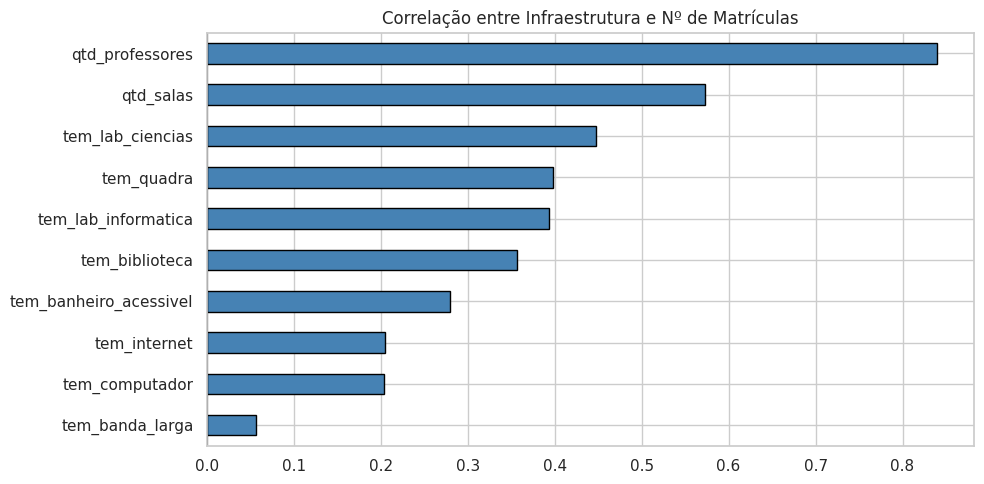

In [20]:
# Correlação entre Infraestrutura e Matrículas

cols_corr = cols_infra + ['qtd_salas', 'qtd_professores', 'qtd_matriculas']

#Criando uma matriz de correlação
#Pegando a coluna referente a matriculas e dropando ela, porque toda variável tem correlação perfeita consigo mesma
corr = dados_pr[cols_corr].corr()[['qtd_matriculas']].drop('qtd_matriculas')

corr.sort_values('qtd_matriculas').plot(
    kind='barh', legend=False, color='steelblue', edgecolor='black'
)
plt.title('Correlação entre Infraestrutura e Nº de Matrículas')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Interpretando os Resultados

| Variável        | Correlação |
| --------------- | ---------- |
| qtd_professores | 0.80       |
| qtd_salas       | 0.55       |
| biblioteca      | 0.30       |
| laboratório     | 0.25       |
| internet        | 0.22       |

**Professores = 0.80** -
Correlação forte e positiva.

Significa que escolas com mais professores tendem a ter mais matrículas.
Não quer dizer que contratar professores faz as matrículas aumentarem. Apenas que as duas coisas aparecem juntas.

**Salas = 0.55** -
Correlação moderada.

Escolas com mais salas costumam ter mais matrículas.

Faz sentido porque:

mais salas → maior capacidade;
mais alunos → mais matrículas.

Observou-se forte associação positiva entre o número de professores e a quantidade de matrículas (r = 0,80), indicando que escolas de maior porte tendem a concentrar maior número de estudantes.



### Modelagem Preditiva

Por que utilizei a Regressão Linear?

Tipo de problema: a variável-alvo qtd_matriculas é um número contínuo (não uma categoria), então o problema é de Regressão.

Natureza dos dados: Números (binários 0/1 + quantidades)


Extra: Validação com LazyPredict, comparamos com 41 algoritmos diferentes: o melhor (Light Gradient Boosting Machine) obteve R²=0.706 contra R²=0.682 da Regressão Linear, uma diferença de apenas 2,4 pontos.


In [21]:
# Modelo v1 - Possui todas as features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features_v1 = [
    'tem_agua_potavel', 'tem_energia', 'tem_esgoto',
    'tem_internet', 'tem_banda_larga', 'tem_computador',
    'tem_biblioteca', 'tem_lab_informatica', 'tem_lab_ciencias',
    'tem_quadra', 'tem_cozinha', 'tem_refeitorio', 'tem_banheiro_acessivel',
    'qtd_salas', 'qtd_professores'
]

X1 = dados_pr[features_v1]
y1 = dados_pr['qtd_matriculas']
# Separando 80% dos dados para treino e 20% para teste
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

Métricas de Avaliação:

| Métrica  | O que mede                                          | Melhor valor         |
| -------- | --------------------------------------------------- | -------------------- |
| **MAE**  | Erro médio das previsões                            | Menor                |
| **RMSE** | Erro médio com maior penalização para erros grandes | Menor                |
| **R²**   | Capacidade do modelo de explicar os dados           | Maior (próximo de 1) |



In [22]:
# Treinar e Avaliar
modelo1 = LinearRegression()

# o modelo aprende a relação entre as variveis X e o n° de matriculas Y usando dados do treino
modelo1.fit(X_train1, y_train1)

#aqui o modelo faz previsões nos dados de teste que ele nunca viu
y_pred1 = modelo1.predict(X_test1)

mae1 = mean_absolute_error(y_test1, y_pred1)
rmse1 = np.sqrt(mean_squared_error(y_test1, y_pred1))
r2_1 = r2_score(y_test1, y_pred1)

print(f"MAE:  {mae1:.2f}")
print(f"RMSE: {rmse1:.2f}")
print(f"R²:   {r2_1:.2f}")

MAE:  81.99
RMSE: 168.39
R²:   0.68


In [23]:
#Visualizar o peso dos coeficientes
coef_df1 = pd.DataFrame({
    'Variável': features_v1,
    'Coeficiente': modelo1.coef_
}).sort_values('Coeficiente', ascending=False)

print(coef_df1)

                  Variável  Coeficiente
1              tem_energia    36.018076
9               tem_quadra    32.099550
2               tem_esgoto    24.104244
14         qtd_professores    13.347049
6           tem_biblioteca    11.522542
12  tem_banheiro_acessivel     4.096570
13               qtd_salas     2.713335
4          tem_banda_larga    -1.249474
7      tem_lab_informatica    -4.193032
5           tem_computador    -6.234830
10             tem_cozinha    -8.628619
8         tem_lab_ciencias   -13.505599
11          tem_refeitorio   -19.115306
3             tem_internet   -28.259781
0         tem_agua_potavel   -54.178872


Problema encontrado: alguns coeficientes não fazem sentido

tem_agua_potavel: -54 (sugeriria que ter água potável reduz matrículas)

tem_internet: -28

tem_refeitorio: -19

## Problema: Multicolinearidade

Observando os coeficientes do Modelo v1, encontrou-se resultados contraintuitivos:

- `tem_agua_potavel`: coeficiente negativo (-54)
- `tem_internet`: coeficiente negativo (-28)

Isso sugeriria que ter água potável ou internet **reduz** o número de matrículas.

**Causa:** as 13 variáveis de infraestrutura são muito correlacionadas entre si
(escolas tendem a ter "tudo" ou "quase nada"). Esse fenômeno é chamado de
**multicolinearidade** e faz os coeficientes individuais ficarem instáveis e
sem interpretação confiável mesmo que o modelo continue prevendo bem (R²=0.68).

**Solução:** consolidar as 13 variáveis binárias em um único **índice de
infraestrutura** (soma de 0 a 13), reduzindo a redundância.

In [24]:
#Modelo v2 - índice de infraestrutura
cols_infra_binarias = [
    'tem_agua_potavel', 'tem_energia', 'tem_esgoto',
    'tem_internet', 'tem_banda_larga', 'tem_computador',
    'tem_biblioteca', 'tem_lab_informatica', 'tem_lab_ciencias',
    'tem_quadra', 'tem_cozinha', 'tem_refeitorio', 'tem_banheiro_acessivel'
]

#soma, linha a linha (escola por escola), os valores das 13 colunas binárias
#gerando um número de 0 a 13 que representa quantos itens de infraestrutura a escola tem
#quanto maior o valor, melhor a infraestrutura da escola
dados_pr['indice_infraestrutura'] = dados_pr[cols_infra_binarias].sum(axis=1)

print(dados_pr['indice_infraestrutura'].describe())


count    9999.000000
mean        9.251725
std         2.744713
min         0.000000
25%         8.000000
50%        10.000000
75%        11.000000
max        13.000000
Name: indice_infraestrutura, dtype: float64


Foi criado um Índice de Infraestrutura por meio da soma de 13 variáveis binárias relacionadas às condições físicas e tecnológicas das escolas. O índice varia de 0 a 13, em que valores maiores indicam melhor infraestrutura. A média observada foi de 9,25 pontos, com mediana igual a 10, indicando que a maioria das escolas possui grande parte dos recursos avaliados. O valor máximo encontrado foi 13, correspondente a escolas que possuem todos os itens considerados.

In [25]:
# Treinar e Avaliar
features_v2 = ['indice_infraestrutura', 'qtd_salas', 'qtd_professores']

X2 = dados_pr[features_v2]
y2 = dados_pr['qtd_matriculas']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

modelo2 = LinearRegression()
modelo2.fit(X_train2, y_train2)

y_pred2 = modelo2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
r2_2 = r2_score(y_test2, y_pred2)

print(f"MAE:  {mae2:.2f}")
print(f"RMSE: {rmse2:.2f}")
print(f"R²:   {r2_2:.2f}")

MAE:  84.56
RMSE: 169.69
R²:   0.68


In [26]:
# Visualizar os pesos dos coeficientes
coef_df2 = pd.DataFrame({
    'Variável': features_v2,
    'Coeficiente': modelo2.coef_
})
print(coef_df2)

                Variável  Coeficiente
0  indice_infraestrutura    -0.520442
1              qtd_salas     2.865343
2        qtd_professores    13.645741


In [27]:
# Comparação final
comparacao = pd.DataFrame({
    'Modelo': ['v1 (15 variáveis)', 'v2 (índice)'],
    'MAE': [mae1, mae2],
    'RMSE': [rmse1, rmse2],
    'R²': [r2_1, r2_2]
})
print(comparacao)

              Modelo        MAE        RMSE        R²
0  v1 (15 variáveis)  81.987583  168.386077  0.682371
1        v2 (índice)  84.555397  169.694121  0.677417


Interpretação das Métricas:

| Métrica  | Valor      | Interpretação                                                                                                                                              |
| -------- | ---------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **MAE**  | **84,56**  | Em média, o modelo erra a previsão em aproximadamente **85 matrículas**.                                                                                   |
| **RMSE** | **169,69** | Penaliza mais os erros grandes. O valor elevado em relação ao MAE indica que existem algumas escolas onde o modelo apresenta erros consideráveis.          |
| **R²**   | **0,68**   | O modelo explica cerca de **68% da variação** no número de matrículas; os **32% restantes** estão associados a fatores não presentes no conjunto de dados. |


In [28]:
# Salvando o modelo
import joblib
joblib.dump(modelo2, 'modelo_matriculas.pkl')
print("Modelo salvo")

Modelo salvo


### Conclusão da Modelagem

O número de matrículas é determinado principalmente pelo porte da escola (quantidade de professores e salas), e não pela quantidade de itens de infraestrutura disponíveis. O coeficiente do índice de infraestrutura (-0.52) é estatisticamente próximo de zero, ou seja, não significa que infraestrutura prejudica matrículas, apenas que, comparado ao porte da escola, esse fator tem efeito quase nulo na previsão.

Isso sugere que investimentos em infraestrutura, embora importantes para a qualidade do ensino, não são o fator que define quantos alunos uma escola atende, esse número está mais ligado à capacidade física/estrutural da escola, possivelmente refletindo a demanda da região.